# **3.6.1 Labeling Method for Multi-Stage Decision Making**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/15CBl6SPM05thYwircCjvhUT4Oc7rvJOG?usp=sharing)

Our first example of the use of the dynamic programming approach involves a choice of transportation routes. **Figure 3.18** shows a system of roads connecting three sources H<sub>i</sub> that generate hazardous by-products with two sites D<sub>j</sub> designated for the disposal of hazardous waste materials. Three political borders, shown by dashed-lines, must be crossed in transit. Each straight-line section of road requires one day’s travel time, so it is a four-day drive from any H<sub>i</sub> to any D<sub>j</sub>. However, at each border crossing, regulations require container inspection and possible recontainerization, and this can cause delays at each checkpoint. The number of days delay that can be anticipated is shown in the circle drawn at each checkpoint. The problem is to determine the routing from generation sites to disposal sites that involves the minimum delays.

&nbsp;&nbsp;&nbsp;&nbsp;The **stages** in this multi-stage decision process correspond to the three borders that must be crossed. In the terminology of dynamic programming, the various checkpoints at each stage are called **states**. Thus, there are four states in the first stage, and three states in each of the second and third stages.

&nbsp;&nbsp;&nbsp;&nbsp;To solve this problem, we take an approach that is similar to the backward labeling method for shortest path through an acyclic graph. Our decisions will be made, beginning with the final stage, Stage 3, and moving backward to the left through the earlier stages. At each stage, we phrase our decision in the following way: for each possible *state* in the current stage, if this state is ever reached, what would be the minimum delay from here to the dump sites? If this question can be answered at every stage, then eventually at the first stage, we will have established our minimum delay route, as desired.

&nbsp;&nbsp;&nbsp;&nbsp;The mechanism that we will use is a backward node-labeling scheme. When we arrive at Stage 3, the delay to the dump site is just the delay at the third border crossing. We label each checkpoint node accordingly, as shown in **Figure 3.19a**.

&nbsp;&nbsp;&nbsp;&nbsp;At Stage 2, the delay at the top node is 5 plus either four or three additional days. We choose the minimum 3 and label that node with 5 + 3 = 8. The other two nodes are labeled in the same way, as shown in **Figure 3.19b**.

<div align="center">

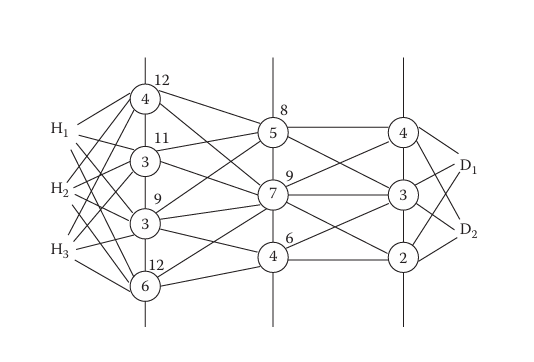

</div>

**FIGURE 3.18** <br>
Hazardous waste disposal routes.

<br>

<div align="center">

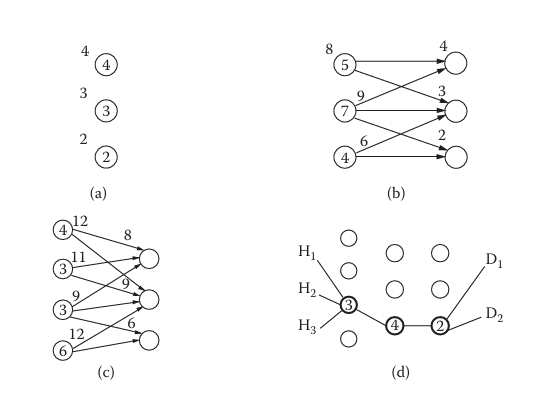

</div>

**FIGURE 3.19** <br>
Minimum delay path: (a) stage 3, (b) stage 2, (c) stage 1, and (d) optimal path.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;Backing up to Stage 1, we similarly compute four labels, as shown in **Figure 3**.19c. Since all four checkpoints at Stage 1 are uniformly accessible from each of the generation sites, we can conclude that the minimum delay path goes through the node labeled 9 at the first border crossing (with a delay of 3). The optimal path is highlighted in **Figure 3.19d**, where the total delay of 9 is obtained by crossing the second border at the bottom node (where delay is 4), and from there crossing the third border at its bottom node (with a delay of 2).

**Code Implementation**

In [ ]:
# ========================================
# 3.6.1 Labeling Method for Multi-Stage Decision Making
# DP Backward Labeling — Figure 3.18 / Figure 3.19
# ========================================

import pandas as pd

# Delays written inside the checkpoint circles
stage3_delays = [4, 3, 2]          # Stage 3 checkpoints
stage2_delays = [5, 7, 4]          # Stage 2 checkpoints
stage1_delays = [4, 3, 3, 6]       # Stage 1 checkpoints

# Connections between stages
# Indexes start at 0 in Python
stage2_to_3 = {
    0: [0, 1],      # Stage 2 Node 1 can go to Stage 3 Nodes 1 or 2
    1: [0, 2],      # Stage 2 Node 2 can go to Stage 3 Nodes 1 or 3
    2: [1, 2]       # Stage 2 Node 3 can go to Stage 3 Nodes 2 or 3
}

stage1_to_2 = {
    0: [0],         # Stage 1 Node 1
    1: [0],         # Stage 1 Node 2
    2: [2],         # Stage 1 Node 3
    3: [2]          # Stage 1 Node 4
}

print("=" * 60)
print("3.6.1 Labeling Method for Multi-Stage Decision Making")
print("Backward Labeling Example")
print("=" * 60)

# ----------------------------
# Stage 3 labels
# ----------------------------
f3 = {}

for i in range(3):
    f3[i] = stage3_delays[i]

stage3_table = pd.DataFrame({
    "Stage 3 Node": [1, 2, 3],
    "Checkpoint Delay": stage3_delays,
    "Label": [f3[i] for i in range(3)]
})

print("\nStage 3 Labels:")
display(stage3_table)

# ----------------------------
# Stage 2 labels
# ----------------------------
f2 = {}
best2 = {}

stage2_rows = []

for i in range(3):
    options = {}

    for j in stage2_to_3[i]:
        options[j] = stage2_delays[i] + f3[j]

    best_j = min(options, key=options.get)

    f2[i] = options[best_j]
    best2[i] = best_j

    stage2_rows.append({
        "Stage 2 Node": i + 1,
        "Checkpoint Delay": stage2_delays[i],
        "Best Next Stage 3 Node": best_j + 1,
        "Label": f2[i]
    })

stage2_table = pd.DataFrame(stage2_rows)

print("\nStage 2 Labels:")
display(stage2_table)

# ----------------------------
# Stage 1 labels
# ----------------------------
f1 = {}
best1 = {}

stage1_rows = []

for i in range(4):
    options = {}

    for j in stage1_to_2[i]:
        options[j] = stage1_delays[i] + f2[j]

    best_j = min(options, key=options.get)

    f1[i] = options[best_j]
    best1[i] = best_j

    stage1_rows.append({
        "Stage 1 Node": i + 1,
        "Checkpoint Delay": stage1_delays[i],
        "Best Next Stage 2 Node": best_j + 1,
        "Label": f1[i]
    })

stage1_table = pd.DataFrame(stage1_rows)

print("\nStage 1 Labels:")
display(stage1_table)

# ----------------------------
# Optimal path
# ----------------------------
best_entry = min(f1, key=f1.get)
stage2_choice = best1[best_entry]
stage3_choice = best2[stage2_choice]

print("\nOptimal Solution:")
print(f"  Stage 1 Node: {best_entry + 1}")
print(f"  Stage 2 Node: {stage2_choice + 1}")
print(f"  Stage 3 Node: {stage3_choice + 1}")
print(f"  Minimum total delay: {f1[best_entry]} days")

print("\nTextbook answer: 9 days")

3.6.1 Labeling Method for Multi-Stage Decision Making
Backward Labeling Example

Stage 3 Labels:


,Stage 3 Node,Checkpoint Delay,Label
0,1,4,4
1,2,3,3
2,3,2,2



Stage 2 Labels:


,Stage 2 Node,Checkpoint Delay,Best Next Stage 3 Node,Label
0,1,5,2,8
1,2,7,3,9
2,3,4,3,6



Stage 1 Labels:


,Stage 1 Node,Checkpoint Delay,Best Next Stage 2 Node,Label
0,1,4,1,12
1,2,3,1,11
2,3,3,3,9
3,4,6,3,12



Optimal Solution:
  Stage 1 Node: 3
  Stage 2 Node: 3
  Stage 3 Node: 3
  Minimum total delay: 9 days

Textbook answer: 9 days
